# LLM Time-Series Anomaly Detection: SFT Pipeline

**参考链接**
- [AnomLLM](https://github.com/Rose-STL-Lab/AnomLLM)
- [Unsloth Vision SFT](https://docs.unsloth.ai/basics/vision-fine-tuning)
- [Unsloth Qwen3-VL](https://docs.unsloth.ai/models/qwen3-vl)
- [vLLM Server](https://docs.vllm.ai/en/latest/serving/openai_compatible_server.html)

**数据**：AnomLLM 合成数据集，4 个子集（flat-trend / range / point / freq），每个 400 条，长度 1000 单通道时序 + 预渲染 PNG

**流程**：Phase 0-1 环境 → Phase 2-4 Baseline → Phase 5-7 SFT 数据 → Phase 8 训练 → Phase 9 评估 → Phase 10 可选 GRPO

**标记说明**
- 🔑 **需要你操作** — 需要填入密钥等信息
- ⏸ **需要你判断** — 查看可视化结果，确认无误后继续
- 📊 可视化 — 过程性检查图表

---
## 阶段 0. 初始化环境

### Cell 0.1 — 挂载 Google Drive

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


### Cell 0.2 — 定义运行目录

In [2]:
from pathlib import Path

RUNTIME    = Path("/content/tsad_runtime")
DRIVE_ROOT = Path("/content/drive/MyDrive/tsad_anomaly")

RT_CODE    = RUNTIME / "code"
RT_SFT     = RUNTIME / "sft"
RT_CKPT    = RUNTIME / "checkpoints"
RT_RESULTS = RUNTIME / "results"

DRV_PACK   = DRIVE_ROOT / "packs"
DRV_SFT    = DRIVE_ROOT / "sft"
DRV_CKPT   = DRIVE_ROOT / "checkpoints"
DRV_RESULTS= DRIVE_ROOT / "results"

for p in [RUNTIME, RT_CODE, RT_SFT, RT_CKPT, RT_RESULTS,
          DRV_PACK, DRV_SFT, DRV_CKPT, DRV_RESULTS]:
    p.mkdir(parents=True, exist_ok=True)

ANOMLLM = RT_CODE / "AnomLLM"

### Cell 0.3 — 安装依赖

In [3]:
!pip install -U pip -q
!pip install "unsloth[colab-new]" -q
!pip install vllm openai accelerate bitsandbytes scikit-learn pandas pyyaml datasets matplotlib pillow trl loguru google-generativeai requests -q
!pip install "git+https://github.com/ahstat/affiliation-metrics-py.git" -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 88.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
opentelemetry-exporter-gcp-logging 1.11.0a0 requires opentelemetry-sdk<1.39.0,>=1.35.0, but you have opentelemetry-sdk 1.40.0 which is incompatible.
google-adk 1.28.0 requires opentelemetry-api<1.39.0,>=1.36.0, but you have opentelemetry-api 1.40.0 which is incompatible.
google-adk 1.28.0 requires opentelemetry-sdk<1.39.0,>=1.36.0, but you have opentelemetry-sdk 1.40.0 which is incompatible.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


---
## 阶段 1. 获取 AnomLLM 代码和数据

### Cell 1.1 — 克隆仓库

In [4]:
%%bash
if [ ! -d /content/tsad_runtime/code/AnomLLM ]; then
  git clone https://github.com/Rose-STL-Lab/AnomLLM.git /content/tsad_runtime/code/AnomLLM
fi

Cloning into '/content/tsad_runtime/code/AnomLLM'...


In [5]:
import os
os.environ["PYTHONPATH"] = "/content/tsad_runtime/code/AnomLLM/src"

### Cell 1.2 — 恢复或下载数据

In [6]:
%%bash
# 优先从 Drive 恢复
if [ -f /content/drive/MyDrive/tsad_anomaly/packs/anomllm_data.tar ]; then
  tar -xf /content/drive/MyDrive/tsad_anomaly/packs/anomllm_data.tar \
      -C /content/tsad_runtime/code/AnomLLM
else
  # 方案 A：从 S3 下载预生成数据
  pip install s5cmd -q
  cd /content/tsad_runtime/code/AnomLLM
  s5cmd --no-sign-request --endpoint-url https://s3-west.nrp-nautilus.io \
      cp "s3://anomllm/data/*" data/

  # 方案 B：本地生成（若 S3 不可用，取消下面注释）
  # cd /content/tsad_runtime/code/AnomLLM && bash synthesize.sh

  # 打包备份到 Drive
  tar -cf /content/drive/MyDrive/tsad_anomaly/packs/anomllm_data.tar \
      -C /content/tsad_runtime/code/AnomLLM data
fi

### Cell 1.3 — 确认数据结构

In [7]:
import pickle, os

for subset in ["point", "range", "freq", "flat-trend"]:
    pkl = f"/content/tsad_runtime/code/AnomLLM/data/synthetic/{subset}/eval/data.pkl"
    with open(pkl, "rb") as f:
        d = pickle.load(f)
    print(subset, "series:", len(d["series"]), d["series"][0].shape,
          "| has_figs:", os.path.isdir(pkl.replace("data.pkl","figs")))

point series: 400 (1000, 1) | has_figs: True
range series: 400 (1000, 1) | has_figs: True
freq series: 400 (1000, 1) | has_figs: True
flat-trend series: 400 (1000, 1) | has_figs: True


### Cell 1.4 — 固定数据子集

In [8]:
DATASETS = ["flat-trend", "range", "point", "freq"]

### 📊 可视化：数据集概览

In [ ]:
import pickle, matplotlib.pyplot as plt

subsets = ["flat-trend", "range", "point", "freq"]
normal_counts, anom_counts = [], []

for subset in subsets:
    with open(f"/content/tsad_runtime/code/AnomLLM/data/synthetic/{subset}/eval/data.pkl", "rb") as f:
        d = pickle.load(f)
    n_anom = sum(1 for a in d["anom"] if len(a[0]) > 0)
    anom_counts.append(n_anom)
    normal_counts.append(len(d["anom"]) - n_anom)

fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(subsets))
ax.bar(x, normal_counts, label="Normal", color="#66BB6A", edgecolor="black")
ax.bar(x, anom_counts, bottom=normal_counts, label="Anomaly", color="#EF5350", edgecolor="black")
ax.set_xticks(x)
ax.set_xticklabels(subsets)
ax.set_ylabel("样本数")
ax.set_title("各子集样本数与异常/正常占比")
ax.legend()
fig.tight_layout()
plt.show()

---
## ⏸ 检查点 A：环境 + 数据就绪

检查：GPU / VRAM / BF16、四个子集各 400 条、`has_figs: True`、上方柱状图合理

In [ ]:
import torch
print("GPU:", torch.cuda.get_device_name(0))
print("Free VRAM:", round(torch.cuda.mem_get_info()[0] / 1e9, 1), "GB")
print("BF16:", torch.cuda.is_bf16_supported())

import unsloth
print("unsloth OK")

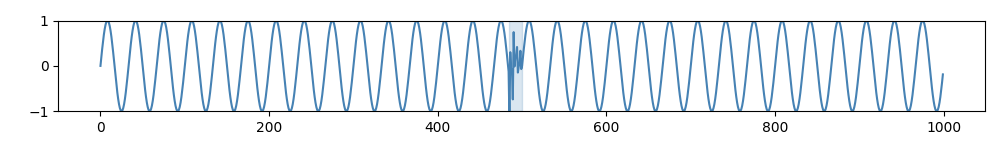

In [10]:
from IPython.display import Image
Image("/content/tsad_runtime/code/AnomLLM/data/synthetic/point/eval/figs/001.png")

---
## 阶段 2. VLM Baseline

### Cell 2.1 — 启动本地 Qwen3-VL endpoint（后台运行）

**⏸ 需要你判断**：运行后等待 vLLM 加载完成，运行下方 health check cell 确认返回 200 后再继续。

In [11]:
!pkill -f "vllm.entrypoints.openai.api_server.*--port 8000" || true

!nohup python -m vllm.entrypoints.openai.api_server \
  --model Qwen/Qwen3-VL-8B-Instruct \
  --served-model-name qwen-local \
  --host 127.0.0.1 --port 8000 \
  --max-model-len 8192 \
  --gpu-memory-utilization 0.95 \
  > /tmp/vllm.log 2>&1 &

^C


### Cell 2.2 — 写 credentials.yml

In [12]:
creds = """\
qwen-local:
  api_key: dummy
  base_url: "http://127.0.0.1:8000/v1"
"""
(ANOMLLM / "credentials.yml").write_text(creds)

68

In [26]:
!tail -n 20 /tmp/vllm.log

(APIServer pid=28722) INFO 04-04 06:28:37 [launcher.py:46] Route: /v1/models, Methods: GET
(APIServer pid=28722) INFO 04-04 06:28:37 [launcher.py:46] Route: /ping, Methods: GET
(APIServer pid=28722) INFO 04-04 06:28:37 [launcher.py:46] Route: /ping, Methods: POST
(APIServer pid=28722) INFO 04-04 06:28:37 [launcher.py:46] Route: /invocations, Methods: POST
(APIServer pid=28722) INFO 04-04 06:28:37 [launcher.py:46] Route: /v1/chat/completions, Methods: POST
(APIServer pid=28722) INFO 04-04 06:28:37 [launcher.py:46] Route: /v1/chat/completions/batch, Methods: POST
(APIServer pid=28722) INFO 04-04 06:28:37 [launcher.py:46] Route: /v1/responses, Methods: POST
(APIServer pid=28722) INFO 04-04 06:28:37 [launcher.py:46] Route: /v1/responses/{response_id}, Methods: GET
(APIServer pid=28722) INFO 04-04 06:28:37 [launcher.py:46] Route: /v1/responses/{response_id}/cancel, Methods: POST
(APIServer pid=28722) INFO 04-04 06:28:37 [launcher.py:46] Route: /v1/completions, Methods: POST
(APIServer pid=2

In [27]:
!curl -i http://127.0.0.1:8000/health

HTTP/1.1 200 OK
date: Sat, 04 Apr 2026 07:01:08 GMT
server: uvicorn
content-length: 0



### Cell 2.3 — 跑 VLM baseline 全量

运行后检查下方可视化 cell 确认输出格式正确。

In [ ]:
%%bash
cd /content/tsad_runtime/code/AnomLLM
for datum in flat-trend range point freq; do
  python src/online_api.py --data "$datum" --model qwen-local --variant 0shot-vision
done

### 📊 可视化：VLM Baseline 输出检查

In [ ]:
from pathlib import Path
import json

root = Path("/content/tsad_runtime/code/AnomLLM/results/synthetic")
subsets = ["flat-trend", "range", "point", "freq"]
expected_ids = {f"{i:05d}" for i in range(1, 401)}

def parse_output_local(output: str):
    trimmed = output[output.index('['):output.rindex(']') + 1]
    parsed = json.loads(trimmed)
    if not isinstance(parsed, list):
        raise ValueError("response is not a list")
    for item in parsed:
        if not isinstance(item, dict):
            raise ValueError("non-dict item")
        if "start" not in item or "end" not in item:
            raise ValueError("missing start/end")
    return parsed

for subset in subsets:
    fn = root / subset / "qwen-local" / "0shot-vision.jsonl"
    assert fn.exists(), f"missing file: {fn}"

    with open(fn) as f:
        lines = f.readlines()

    seen = set()
    bad = []

    for line_no, line in enumerate(lines, 1):
        try:
            obj = json.loads(line)
            assert {"custom_id", "request", "response"} <= obj.keys()
            seen.add(obj["custom_id"].split("_")[-1])
            parse_output_local(obj["response"])
        except Exception as e:
            bad.append((line_no, str(e)))

    missing = sorted(expected_ids - seen)

    print(f"\n[{subset}]")
    print("lines:", len(lines))
    print("missing_ids:", len(missing))
    print("bad_rows:", len(bad))

    if missing:
        print("missing sample:", missing[:10])
    if bad:
        print("bad sample:", bad[:3])

print("\n检查完成")


[flat-trend]
lines: 400
missing_ids: 0
bad_rows: 0

[range]
lines: 400
missing_ids: 0
bad_rows: 0

[point]
lines: 400
missing_ids: 0
bad_rows: 0

[freq]
lines: 400
missing_ids: 0
bad_rows: 0

检查完成


---
## 阶段 3. 统计 Baseline

### Cell 3.1 — Isolation Forest

In [ ]:
%%bash
cd /content/tsad_runtime/code/AnomLLM
for datum in flat-trend range point freq; do
  python src/baselines/isoforest.py --data "$datum" --model isolation-forest
done

---
## 阶段 4. 汇总 Baseline 对比

### Cell 4.1 — result_agg.py 生成指标

In [ ]:
%%bash
cd /content/tsad_runtime/code/AnomLLM
mkdir -p results/agg

python src/result_agg.py --data_name flat-trend --label_name flat-trend-exp \
    --table_caption "Trend anomalies (flat)"
python src/result_agg.py --data_name range --label_name range-exp \
    --table_caption "Out-of-range anomalies"
python src/result_agg.py --data_name point --label_name point-exp \
    --table_caption "Point anomalies"
python src/result_agg.py --data_name freq --label_name freq-exp \
    --table_caption "Frequency anomalies"

### Cell 4.2 — 合并成对比 CSV

In [ ]:
import pickle, pandas as pd

frames = []
for datum in ["flat-trend", "range", "point", "freq"]:
    with open(f"/content/tsad_runtime/code/AnomLLM/results/agg/{datum}.pkl", "rb") as f:
        df = pickle.load(f)
    df.insert(0, "dataset", datum)
    frames.append(df)

baseline_df = pd.concat(frames)
baseline_df.to_csv("/content/tsad_runtime/results/baseline_compare.csv")
print(baseline_df.to_string())

                                  dataset  precision    recall        f1  affi precision  affi recall   affi f1
model            variant                                                                                       
isolation-forest 0shot         flat-trend   0.065295  0.203268  0.092815        0.223412     0.422302  0.292167
qwen-local       0shot-vision  flat-trend   0.575000  0.575000  0.575000        0.575000     0.575000  0.575000
isolation-forest 0shot              range   0.158695  0.697488  0.236693        0.423843     0.697500  0.524988
qwen-local       0shot-vision       range   0.459190  0.633757  0.493413        0.914767     0.906340  0.905018
isolation-forest 0shot              point   0.033785  0.704710  0.061788        0.356710     0.707500  0.474320
qwen-local       0shot-vision       point   0.516058  0.641005  0.545357        0.902663     0.888222  0.889508
isolation-forest 0shot               freq   0.034058  0.900000  0.064442        0.452705     0.900000  0

---
## ⏸ 检查点 B：Baseline 完成

检查：所有 jsonl 均 400 行、各子集 F1 非零（期望 0.2~0.7）

In [ ]:
%%bash
echo "=== VLM baseline ==="
wc -l /content/tsad_runtime/code/AnomLLM/results/synthetic/*/qwen-local/0shot-vision.jsonl
echo "=== Isolation Forest ==="
wc -l /content/tsad_runtime/code/AnomLLM/results/synthetic/*/isolation-forest/0shot.jsonl

=== VLM baseline ===
     400 /content/tsad_runtime/code/AnomLLM/results/synthetic/flat-trend/qwen-local/0shot-vision.jsonl
     400 /content/tsad_runtime/code/AnomLLM/results/synthetic/freq/qwen-local/0shot-vision.jsonl
     400 /content/tsad_runtime/code/AnomLLM/results/synthetic/point/qwen-local/0shot-vision.jsonl
     400 /content/tsad_runtime/code/AnomLLM/results/synthetic/range/qwen-local/0shot-vision.jsonl
    1600 total
=== Isolation Forest ===
    400 /content/tsad_runtime/code/AnomLLM/results/synthetic/flat-trend/isolation-forest/0shot.jsonl
    400 /content/tsad_runtime/code/AnomLLM/results/synthetic/freq/isolation-forest/0shot.jsonl
    400 /content/tsad_runtime/code/AnomLLM/results/synthetic/point/isolation-forest/0shot.jsonl
    400 /content/tsad_runtime/code/AnomLLM/results/synthetic/range/isolation-forest/0shot.jsonl
   1600 total


In [ ]:
import pandas as pd
print(pd.read_csv("/content/tsad_runtime/results/baseline_compare.csv").to_string())

              model       variant     dataset  precision    recall        f1  affi precision  affi recall   affi f1
0  isolation-forest         0shot  flat-trend   0.065295  0.203267  0.092815        0.223412     0.422302  0.292167
1        qwen-local  0shot-vision  flat-trend   0.575000  0.575000  0.575000        0.575000     0.575000  0.575000
2  isolation-forest         0shot       range   0.158695  0.697488  0.236693        0.423843     0.697500  0.524988
3        qwen-local  0shot-vision       range   0.459190  0.633757  0.493412        0.914767     0.906340  0.905018
4  isolation-forest         0shot       point   0.033785  0.704710  0.061788        0.356710     0.707500  0.474320
5        qwen-local  0shot-vision       point   0.516058  0.641005  0.545357        0.902663     0.888222  0.889508
6  isolation-forest         0shot        freq   0.034057  0.900000  0.064442        0.452705     0.900000  0.602513
7        qwen-local  0shot-vision        freq   0.166563  0.165030  0.16

In [ ]:
# ── 备份：检查点 B 之前所有中途文件 → Drive (tar.gz) ──
import tarfile, time
from pathlib import Path

RUNTIME    = Path("/content/tsad_runtime")
DRIVE_ROOT = Path("/content/drive/MyDrive/tsad_anomaly")
ANOMLLM    = RUNTIME / "code" / "AnomLLM"
SUBSETS    = ["flat-trend", "range", "point", "freq"]

ts = time.strftime("%Y%m%d_%H%M%S")
archive_path = DRIVE_ROOT / "packs" / f"before_ckptB_{ts}.tar.gz"
archive_path.parent.mkdir(parents=True, exist_ok=True)

sources = []

# 1) baseline inference jsonl + log (qwen-local & isolation-forest)
for subset in SUBSETS:
    for model in ["qwen-local/0shot-vision", "isolation-forest/0shot"]:
        for kind in ["results", "logs"]:
            ext = ".jsonl" if kind == "results" else ".log"
            src = ANOMLLM / kind / "synthetic" / subset / (model + ext)
            if src.exists():
                sources.append((src, src.relative_to(RUNTIME)))

# 2) agg pkl files
agg_dir = ANOMLLM / "results" / "agg"
if agg_dir.exists():
    for pkl in agg_dir.glob("*.pkl"):
        sources.append((pkl, pkl.relative_to(RUNTIME)))

# 3) baseline_compare.csv
bc = RUNTIME / "results" / "baseline_compare.csv"
if bc.exists():
    sources.append((bc, bc.relative_to(RUNTIME)))

# 4) eval data.pkl + figs (per subset)
for subset in SUBSETS:
    eval_dir = ANOMLLM / "data" / "synthetic" / subset / "eval"
    if eval_dir.exists():
        for f in eval_dir.rglob("*"):
            if f.is_file():
                sources.append((f, f.relative_to(RUNTIME)))

with tarfile.open(archive_path, "w:gz") as tar:
    for abs_path, arc_name in sources:
        tar.add(abs_path, arcname=str(arc_name))

print(f"✅ 已打包 {len(sources)} 个文件 → {archive_path}")


✅ 已打包 1625 个文件 → /content/drive/MyDrive/tsad_anomaly/packs/before_ckptB_20260404_065756.tar.gz


---
## 阶段 5. 构建 SFT 样本清单

### Cell 5.1 — 生成 sft_manifest.csv

数据来源：已加载的 eval split，无需重新渲染图像（`figs/` 已有 PNG）。

分层切分：1200 train / 150 val / 150 eval

In [ ]:
import pickle, pandas as pd
from sklearn.model_selection import train_test_split

rows = []
for subset in ["flat-trend", "range", "point", "freq"]:
    pkl_path = f"/content/tsad_runtime/code/AnomLLM/data/synthetic/{subset}/eval/data.pkl"
    with open(pkl_path, "rb") as f:
        d = pickle.load(f)
    anom_type = {"flat-trend": "trend", "range": "range",
                 "point": "point", "freq": "freq"}[subset]
    for i, anom_list in enumerate(d["anom"]):
        intervals = anom_list[0]   # sensor 0
        label = 1 if len(intervals) > 0 else 0
        rows.append({
            "sample_id":   f"{subset}_{i:03d}",
            "subset":      subset,
            "pkl_path":    pkl_path,
            "pkl_idx":     i,
            "image_path":  f"/content/tsad_runtime/code/AnomLLM/data/synthetic/{subset}/eval/figs/{i+1:03d}.png",
            "label":       label,
            "anomaly_type": anom_type if label else "none",
            "intervals":   str(intervals),
        })

manifest = pd.DataFrame(rows)

# stratified split: 1200 train / 150 val / 150 eval
train_df, tmp_df = train_test_split(
    manifest, test_size=0.20, random_state=3407,
    stratify=manifest["subset"].astype(str) + "_" + manifest["label"].astype(str)
)
val_df, eval_df = train_test_split(
    tmp_df, test_size=0.50, random_state=3407,
    stratify=tmp_df["subset"].astype(str) + "_" + tmp_df["label"].astype(str)
)
train_df = train_df.assign(split="train")
val_df   = val_df.assign(split="val")
eval_df  = eval_df.assign(split="eval")

manifest = pd.concat([train_df, val_df, eval_df]).sort_values("sample_id")
manifest.to_csv("/content/tsad_runtime/sft/sft_manifest.csv", index=False)
print(manifest["split"].value_counts())
print(manifest.groupby(["split","label"]).size())

split
train    1280
eval      160
val       160
Name: count, dtype: int64
split  label
eval   0         50
       1        110
train  0        407
       1        873
val    0         51
       1        109
dtype: int64


### 📊 可视化：SFT 样本分布

/tmp/ipykernel_4370/4270390736.py:23: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_4370/4270390736.py:23: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_4370/4270390736.py:23: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_4370/4270390736.py:23: UserWarning: Glyph 25353 (\N{CJK UNIFIED IDEOGRAPH-6309}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_4370/4270390736.py:23: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_4370/4270390736.py:23: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_4370/4270390736.py:23: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}

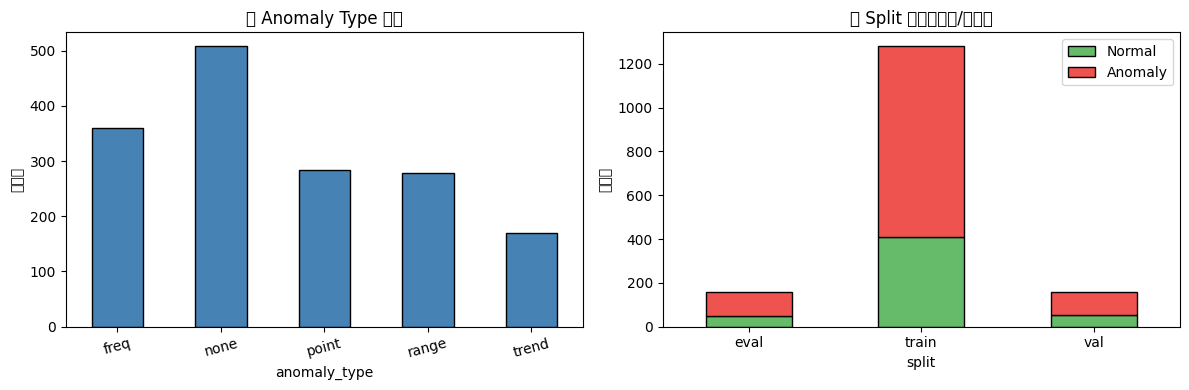

总样本数: 1600  |  train=1280 val=160 eval=160


In [ ]:
import pandas as pd, matplotlib.pyplot as plt

manifest = pd.read_csv("/content/tsad_runtime/sft/sft_manifest.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 左：按 anomaly_type 分布
type_counts = manifest["anomaly_type"].value_counts().sort_index()
type_counts.plot.bar(ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("按 Anomaly Type 分布")
axes[0].set_ylabel("样本数")
axes[0].tick_params(axis="x", rotation=15)

# 右：按 split 分布（stacked by label）
split_label = manifest.groupby(["split", "label"]).size().unstack("label", fill_value=0)
split_label.columns = ["Normal", "Anomaly"]
split_label.plot.bar(ax=axes[1], stacked=True, color=["#66BB6A", "#EF5350"], edgecolor="black")
axes[1].set_title("按 Split 分布（正常/异常）")
axes[1].set_ylabel("样本数")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend()

fig.tight_layout()
plt.show()
print(f"总样本数: {len(manifest)}  |  train={len(manifest[manifest.split=='train'])} "
      f"val={len(manifest[manifest.split=='val'])} eval={len(manifest[manifest.split=='eval'])}")

---
## 阶段 6. 教师蒸馏与清洗

### Cell 6.1 — 设置教师模型

**🔑 需要你操作**：将下方 `sk-xxxx` 替换为你的百炼 API Key，这是整个 notebook 中**唯一需要手动修改**的地方。

In [ ]:
import os
os.environ["DASHSCOPE_API_KEY"] = "sk-xxxx"  # 🔑 替换为你的百炼 API Key

TEACHER_MODEL = "qwen3.5-plus"
TEACHER_TEMPERATURE = 0.2

### Cell 6.2a — 蒸馏冒烟（20 条）

先用 20 条样本验证教师 API 连通性和返回格式。

In [ ]:
import base64, json, pandas as pd
from openai import OpenAI

client = OpenAI(
    api_key=os.environ["DASHSCOPE_API_KEY"],
    base_url="https://dashscope.aliyuncs.com/compatible-mode/v1",
)

SYSTEM = "You are annotating time-series anomaly plots for supervised fine-tuning. Return strict JSON only."
VISION_USER_TEXT = ("Detect ranges of anomalies in this time series, "
                    "in terms of the x-axis coordinate.\n"
                    "List one by one, in JSON format.\n"
                    "If there are no anomalies, answer with an empty list [].\n\n"
                    "Output template:\n"
                    '[{\"start\": ..., \"end\": ...}, {\"start\": ..., \"end\": ...}...]')
USER = (f"{VISION_USER_TEXT}\n\n"
        "Return a strict JSON object with keys: "
        "is_anomaly (bool), anomaly_type (point|range|freq|trend|none), "
        "intervals ([{\"start\": int, \"end\": int}, ...] or []), rationale (str). "
        "No markdown.")

def distill_batch(df, out_path):
    with open(out_path, "w") as fout:
        for _, row in df.iterrows():
            with open(row["image_path"], "rb") as f:
                b64 = base64.b64encode(f.read()).decode()
            resp = client.chat.completions.create(
                model=TEACHER_MODEL,
                messages=[
                    {"role": "system", "content": SYSTEM},
                    {"role": "user", "content": [
                        {"type": "text", "text": USER},
                        {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{b64}"}},
                    ]},
                ],
                response_format={"type": "json_object"},
                extra_body={"enable_thinking": False},
                temperature=TEACHER_TEMPERATURE,
            )
            result = json.loads(resp.choices[0].message.content)
            result["sample_id"]      = row["sample_id"]
            result["image_path"]     = row["image_path"]
            result["ground_truth"]   = int(row["label"])
            result["split"]          = row["split"]
            fout.write(json.dumps(result, ensure_ascii=False) + "\n")
    print(f"写入 {out_path}，共 {len(df)} 条")

manifest = pd.read_csv("/content/tsad_runtime/sft/sft_manifest.csv")
sft_df   = manifest[manifest["split"].isin(["train", "val"])]

# ---- 冒烟：只跑 20 条 ----
distill_batch(sft_df.head(20), "/content/tsad_runtime/sft/sft_raw_smoke.jsonl")

### 📊 可视化：蒸馏冒烟质量检查

In [ ]:
import json

records = []
with open("/content/tsad_runtime/sft/sft_raw_smoke.jsonl") as f:
    for line in f:
        records.append(json.loads(line))

# 一致性统计
match = sum(1 for r in records if bool(r.get("is_anomaly", False)) == bool(r["ground_truth"]))
total = len(records)

# intervals 格式合法性
def valid_interval(iv):
    return (isinstance(iv, dict)
            and isinstance(iv.get("start"), (int, float))
            and isinstance(iv.get("end"), (int, float))
            and iv["start"] < iv["end"])

fmt_ok = sum(1 for r in records
             if isinstance(r.get("intervals", []), list)
             and all(valid_interval(iv) for iv in r.get("intervals", [])))

print(f"冒烟样本数: {total}")
print(f"is_anomaly 与 ground_truth 一致: {match}/{total} ({match/total:.0%})")
print(f"intervals 格式合法: {fmt_ok}/{total} ({fmt_ok/total:.0%})")

print("\n--- 前 5 条蒸馏结果 ---")
for r in records[:5]:
    print(f"  {r['sample_id']} | gt={r['ground_truth']} teacher={r.get('is_anomaly')} "
          f"intervals={r.get('intervals')}")

if match / total >= 0.7 and fmt_ok / total >= 0.7:
    print("\n✅ 冒烟质量合格，可继续运行全量蒸馏")
else:
    print("\n⚠️ 质量不足，请检查教师 prompt 或 API 返回")

**⏸ 需要你判断**：检查上方蒸馏冒烟结果。一致率 ≥ 70% 且格式合法率 ≥ 70% 即可继续运行下方全量蒸馏 cell。

> 若质量不足 → 检查 API Key 是否正确、教师模型是否可用。

### Cell 6.2b — 全量蒸馏

对所有 train + val 样本调用教师模型。

In [ ]:
# 全量蒸馏（复用上面定义的 distill_batch / client / sft_df）
distill_batch(sft_df, "/content/tsad_runtime/sft/sft_raw.jsonl")

### Cell 6.3 — 自动清洗（label 一致 + intervals 格式合法才保留）

对全量蒸馏结果 `sft_raw.jsonl` 进行清洗。

In [ ]:
import json

def valid_interval(interval):
    return (
        isinstance(interval, dict)
        and isinstance(interval.get("start"), (int, float))
        and isinstance(interval.get("end"), (int, float))
        and interval["start"] < interval["end"]
    )

clean, reject = [], []
with open("/content/tsad_runtime/sft/sft_raw.jsonl") as f:
    for line in f:
        r = json.loads(line)
        intervals = r.get("intervals", [])
        teacher_anom = bool(r.get("is_anomaly", False))
        ground_truth = bool(r["ground_truth"])
        intervals_ok = isinstance(intervals, list) and all(valid_interval(iv) for iv in intervals)
        consistent = intervals_ok and (teacher_anom == bool(intervals))
        if teacher_anom == ground_truth and consistent:
            clean.append(r)
        else:
            reject.append(r)

with open("/content/tsad_runtime/sft/sft_final.jsonl", "w") as f:
    for r in clean:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")

print(f"clean={len(clean)}, reject={len(reject)}, "
      f"keep_rate={len(clean)/(len(clean)+len(reject)):.1%}")

### 📊 可视化：蒸馏清洗统计

In [ ]:
import json, matplotlib.pyplot as plt

raw_count = sum(1 for _ in open("/content/tsad_runtime/sft/sft_raw.jsonl"))
clean_count = sum(1 for _ in open("/content/tsad_runtime/sft/sft_final.jsonl"))
reject_count = raw_count - clean_count
keep_rate = clean_count / raw_count if raw_count else 0.0

interval_counts = []
with open("/content/tsad_runtime/sft/sft_final.jsonl") as f:
    for line in f:
        r = json.loads(line)
        interval_counts.append(len(r.get("intervals", [])))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if raw_count > 0:
    axes[0].pie([clean_count, reject_count],
                labels=[f"Clean ({clean_count})", f"Reject ({reject_count})"],
                autopct="%1.1f%%", colors=["#4CAF50", "#F44336"])
    axes[0].set_title(f"蒸馏清洗结果（保留率 {keep_rate:.0%}）")
else:
    axes[0].text(0.5, 0.5, "sft_raw.jsonl 为空", ha="center", va="center")
    axes[0].set_title("蒸馏清洗结果")
    axes[0].axis("off")

if interval_counts:
    axes[1].hist(interval_counts, bins=range(0, max(interval_counts) + 2),
                 edgecolor="black", alpha=0.7, align="left")
    axes[1].set_xlabel("Anomaly Intervals 数量")
    axes[1].set_ylabel("样本数")
    axes[1].set_title("Clean 样本的 Intervals 数量分布")
else:
    axes[1].text(0.5, 0.5, "无 clean 样本", ha="center", va="center")
    axes[1].set_title("Clean 样本的 Intervals 数量分布")
    axes[1].axis("off")

fig.tight_layout()
plt.show()
print(f"raw={raw_count}, clean={clean_count}, reject={reject_count}")

---
## 阶段 7. 转成 Unsloth 训练格式

### Cell 7.1 — 生成 messages 格式 JSONL

In [ ]:
import json

USER_TEXT = VISION_USER_TEXT

writers = {
    "train": open("/content/tsad_runtime/sft/train.jsonl", "w"),
    "val":   open("/content/tsad_runtime/sft/val.jsonl",   "w"),
}

with open("/content/tsad_runtime/sft/sft_final.jsonl") as f:
    for line in f:
        r = json.loads(line)
        assistant = json.dumps(r.get("intervals", []), ensure_ascii=False)
        record = {"messages": [
            {"role": "user", "content": [
                {"type": "text",  "text":  USER_TEXT},
                {"type": "image", "image": r["image_path"]},
            ]},
            {"role": "assistant", "content": assistant},
        ]}
        writers[r["split"]].write(json.dumps(record, ensure_ascii=False) + "\n")

for f in writers.values():
    f.close()

### Cell 7.2 — eval split 单独转（导出评估元数据）

In [ ]:
import json, pandas as pd

manifest = pd.read_csv("/content/tsad_runtime/sft/sft_manifest.csv")
eval_rows = manifest[manifest["split"] == "eval"]

with open("/content/tsad_runtime/sft/eval.jsonl", "w") as f:
    for _, row in eval_rows.iterrows():
        record = {
            "sample_id":   row["sample_id"],
            "image_path":  row["image_path"],
            "label":       int(row["label"]),
            "anomaly_type": row["anomaly_type"],
            "intervals":   row["intervals"],
        }
        f.write(json.dumps(record, ensure_ascii=False) + "\n")

---
## 阶段 8. SFT 训练（Unsloth 官方范式）

### Cell 8.1 — 加载模型

In [ ]:
!pkill -f "vllm.entrypoints.openai.api_server.*--port 8000" || true

from datasets import load_dataset
from unsloth import FastVisionModel

model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Qwen3-VL-8B-Instruct-bnb-4bit",
    load_in_4bit=True,
    use_gradient_checkpointing="unsloth",
)

model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers=True,
    finetune_language_layers=True,
    finetune_attention_modules=True,
    finetune_mlp_modules=True,
    r=16,
    lora_alpha=16,
    lora_dropout=0.0,
    target_modules="all-linear",
)

train_dataset = load_dataset("json", data_files=str(RT_SFT / "train.jsonl"), split="train")
val_dataset   = load_dataset("json", data_files=str(RT_SFT / "val.jsonl"),   split="train")

### Cell 8.2a — 训练冒烟（5 steps）

用 5 步验证训练流程无 OOM、loss 非 nan。

In [ ]:
from trl import SFTConfig, SFTTrainer
from unsloth.trainer import UnslothVisionDataCollator

sft_args = SFTConfig(
    output_dir=str(RT_CKPT / "qwen3vl-tsad"),
    max_length=None,
    num_train_epochs=3,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    learning_rate=2e-5,
    bf16=True,
    logging_steps=1,
    eval_strategy="no",
    save_strategy="no",
    optim="adamw_8bit",
    report_to="none",
    remove_unused_columns=False,
    max_steps=5,  # 冒烟：仅 5 步
)

trainer = SFTTrainer(
    model=model,
    args=sft_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=UnslothVisionDataCollator(model, tokenizer),
)

trainer.train()

### 📊 可视化：训练冒烟 Loss

In [ ]:
import matplotlib.pyplot as plt, math

smoke_loss = [x["loss"] for x in trainer.state.log_history if "loss" in x]
steps = list(range(1, len(smoke_loss) + 1))

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(steps, smoke_loss, "o-", label="train loss")
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("训练冒烟 Loss（前 5 步）")
ax.legend()
fig.tight_layout()
plt.show()

has_nan = any(math.isnan(l) for l in smoke_loss)
print(f"Loss 值: {smoke_loss}")
print(f"是否有 nan: {has_nan}")
if has_nan:
    print("⚠️ 出现 nan，请勿继续，需要降低 learning_rate 后从 Cell 8.1 重跑")
elif smoke_loss[0] < 0.5 or smoke_loss[0] > 10:
    print(f"⚠️ 初始 loss={smoke_loss[0]:.2f} 偏离正常范围 [0.5, 10]，请检查")
else:
    print("✅ 冒烟通过，可以继续运行完整训练")

**⏸ 需要你判断**：检查上方 loss 曲线，确认 loss 在合理范围（1.5~4）且非 nan。若正常，继续运行下方完整训练 cell。

> 若 OOM → 需从 Cell 8.1 重新加载模型；若 loss=nan → 降低 lr 后重跑。

### Cell 8.2b — 完整训练

重新初始化 trainer 并进行完整训练（无 `max_steps` 限制）。

In [ ]:
import gc, torch
del trainer, model
gc.collect()
torch.cuda.empty_cache()

# 重新加载模型（冒烟已污染权重）
from unsloth import FastVisionModel

model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Qwen3-VL-8B-Instruct-bnb-4bit",
    load_in_4bit=True,
    use_gradient_checkpointing="unsloth",
)
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers=True,
    finetune_language_layers=True,
    finetune_attention_modules=True,
    finetune_mlp_modules=True,
    r=16, lora_alpha=16, lora_dropout=0.0,
    target_modules="all-linear",
)

from datasets import load_dataset
train_dataset = load_dataset("json", data_files=str(RT_SFT / "train.jsonl"), split="train")
val_dataset   = load_dataset("json", data_files=str(RT_SFT / "val.jsonl"),   split="train")

from trl import SFTConfig, SFTTrainer
from unsloth.trainer import UnslothVisionDataCollator

sft_args = SFTConfig(
    output_dir=str(RT_CKPT / "qwen3vl-tsad"),
    max_length=None,
    num_train_epochs=3,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    learning_rate=1e-4,
    bf16=True,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,
    save_total_limit=2,
    optim="adamw_8bit",
    report_to="none",
    remove_unused_columns=False,
)

trainer = SFTTrainer(
    model=model,
    args=sft_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=UnslothVisionDataCollator(model, tokenizer),
)

trainer.train()

### 📊 可视化：完整训练 Loss 曲线

In [ ]:
import matplotlib.pyplot as plt

train_steps = [x["step"] for x in trainer.state.log_history if "loss" in x]
train_loss  = [x["loss"] for x in trainer.state.log_history if "loss" in x]
eval_steps  = [x["step"] for x in trainer.state.log_history if "eval_loss" in x]
eval_loss   = [x["eval_loss"] for x in trainer.state.log_history if "eval_loss" in x]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_steps, train_loss, label="train loss", alpha=0.7)
if eval_loss:
    ax.plot(eval_steps, eval_loss, "o-", label="eval loss", markersize=4)
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("SFT 训练 Loss 曲线")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

print(f"最终 train loss: {train_loss[-1]:.4f}")
if eval_loss:
    print(f"最终 eval loss:  {eval_loss[-1]:.4f}")

---
## ⏸ 检查点 C：训练完成

检查上方 loss 曲线是否正常收敛，然后运行下方验证 cell。

In [ ]:
import json, os

# 蒸馏质量：前 5 条
print("=== 蒸馏样本（前 5 条）===")
with open("/content/tsad_runtime/sft/sft_raw.jsonl") as f:
    for _ in range(5):
        print(json.dumps(json.loads(f.readline()), indent=2, ensure_ascii=False))

# 格式验证
print("\n=== 格式验证 ===")
with open("/content/tsad_runtime/sft/train.jsonl") as f:
    r = json.loads(f.readline())
user_content = r["messages"][0]["content"]
image_item = next(item for item in user_content if item["type"] == "image")
assistant = json.loads(r["messages"][1]["content"])
assistant_ok = isinstance(assistant, list) and all(
    isinstance(iv, dict) and {"start", "end"} <= set(iv)
    for iv in assistant
)
print("image exists:", os.path.exists(image_item["image"]))
print("assistant json ok:", assistant_ok)
print("assistant preview:", assistant[:2])

### Cell 8.3 — 导出模型

训练完成后运行此 cell 导出。

In [ ]:
model.save_pretrained_merged(RT_SFT / "qwen3vl-tsad-merged", tokenizer)
model.save_pretrained(RT_SFT / "qwen3vl-tsad-adapter")

---
## 阶段 9. 对比 SFT 与 Baseline

baseline 在 400 条上算过指标，SFT eval 只有 150 条（跨 4 个子集）。**必须把 baseline 结果过滤到相同的 150 条**，才能公平对比。

### Cell 9.1 — 启动 SFT 模型 vLLM server 并推理

**⏸ 需要你判断**：运行后等待 vLLM 加载完成，确认 health check 返回 200 后再继续。

In [ ]:
!pkill -f "vllm.entrypoints.openai.api_server.*--port 8000" || true

!pkill -f "vllm.entrypoints.openai.api_server.*--port 8001" || true

!nohup python -m vllm.entrypoints.openai.api_server \
  --model /content/tsad_runtime/sft/qwen3vl-tsad-merged \
  --served-model-name sft-model \
  --host 127.0.0.1 --port 8001 \
  > /tmp/sft-vllm.log 2>&1 &

In [ ]:
import yaml

creds_path = ANOMLLM / "credentials.yml"
creds = yaml.safe_load(creds_path.read_text()) or {}
creds["sft-model"] = {"api_key": "dummy", "base_url": "http://127.0.0.1:8001/v1"}
creds_path.write_text(yaml.safe_dump(creds, sort_keys=False))

In [ ]:
%%bash
cd /content/tsad_runtime/code/AnomLLM
for datum in flat-trend range point freq; do
  python src/online_api.py --data "$datum" --model sft-model --variant 0shot-vision
done

### Cell 9.2 — 在相同的 eval 150 条上计算 SFT 与 baseline 指标

In [ ]:
import json, sys, pickle, numpy as np, pandas as pd
sys.path.insert(0, "/content/tsad_runtime/code/AnomLLM/src")
from utils import compute_metrics, interval_to_vector, load_results

# 1. 读取 eval split，建立 {subset: [pkl_idx, ...]} 映射
eval_manifest = pd.read_csv("/content/tsad_runtime/sft/sft_manifest.csv")
eval_manifest = eval_manifest[eval_manifest["split"] == "eval"]
eval_indices = {}
for subset, grp in eval_manifest.groupby("subset"):
    eval_indices[subset] = grp["pkl_idx"].tolist()

# 2. 加载 eval 数据集的 ground truth
gt_map = {}
for subset in ["flat-trend", "range", "point", "freq"]:
    with open(f"/content/tsad_runtime/code/AnomLLM/data/synthetic/{subset}/eval/data.pkl","rb") as f:
        d = pickle.load(f)
    for idx in eval_indices.get(subset, []):
        intervals = d["anom"][idx][0]
        gt_map[(subset, idx)] = interval_to_vector(
            [{"start": s, "end": e} for s, e in intervals]
        ).flatten()

# 3. 对每个方法提取 eval 样本的预测，计算指标
def eval_metrics(method_label, result_fn, eval_indices_map, gt_map):
    results_raw = load_results(result_fn, raw=False)
    rows = []
    for subset, idxs in eval_indices_map.items():
        for idx in idxs:
            pred = results_raw[idx]
            gt   = gt_map[(subset, idx)]
            if pred is None:
                pred = np.zeros_like(gt)
            m = compute_metrics(gt.reshape(-1,1), pred.reshape(-1,1).astype(int))
            rows.append({"method": method_label, "subset": subset, **m})
    return pd.DataFrame(rows)

BASE_DIR = "/content/tsad_runtime/code/AnomLLM/results/synthetic"
all_frames = []
for subset in ["flat-trend", "range", "point", "freq"]:
    for method, fn in [
        ("isolation-forest", f"{BASE_DIR}/{subset}/isolation-forest/0shot.jsonl"),
        ("qwen-local-0shot",  f"{BASE_DIR}/{subset}/qwen-local/0shot-vision.jsonl"),
        ("sft-0shot",         f"{BASE_DIR}/{subset}/sft-model/0shot-vision.jsonl"),
    ]:
        all_frames.append(eval_metrics(method, fn, {subset: eval_indices[subset]}, gt_map))

result_df = pd.concat(all_frames)
summary = result_df.groupby("method")[["f1", "affi f1"]].mean().round(3)
print(summary)
summary.to_csv("/content/tsad_runtime/results/sft_eval_metrics.csv")

### 📊 可视化：SFT vs Baseline 最终对比

In [ ]:
import matplotlib.pyplot as plt

pivot_f1 = result_df.groupby(["subset", "method"])["f1"].mean().unstack("method")
pivot_affi = result_df.groupby(["subset", "method"])["affi f1"].mean().unstack("method")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pivot_f1.plot.bar(ax=axes[0], rot=15)
axes[0].set_title("Point-wise F1 by Subset")
axes[0].set_ylabel("F1")
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 1)

pivot_affi.plot.bar(ax=axes[1], rot=15)
axes[1].set_title("Affiliation F1 by Subset")
axes[1].set_ylabel("Affi F1")
axes[1].legend(fontsize=8)
axes[1].set_ylim(0, 1)

fig.tight_layout()
plt.show()

---
## ⏸ 检查点 D：最终对比

查看上方图表：
- SFT 是否比 VLM zero-shot 有提升（F1 高 ≥ 0.03 为可见提升）
- 有无某个子集明显退步

> 进入 GRPO 需满足：SFT F1 高 ≥ 0.05、蒸馏保留率 ≥ 70%、还有剩余 session 时间。

---
## 阶段 10. 可选 GRPO

条件：baseline 对比完成 + SFT 有可见提升 + 蒸馏数据质量稳定。

沿用 Unsloth 官方 VLM RL/GRPO 范式，同一份 `train/val/eval` 数据。

**到达此阶段时，将检查点 D 的结果告诉 Claude Code，由其生成 GRPO 训练 cell。**